<a href="https://colab.research.google.com/github/prangancode/lane-detection-using-semantic-models-for-bd-complex-road-scenarios/blob/main/Deeplabv3_lane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount Google Drive

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# Python libraries

In [ ]:
import os
import json
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm



import albumentations as A
from albumentations.pytorch import ToTensorV2


from PIL import Image
import random

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Utility Function to Load Paths

In [ ]:
import os

def load_image_mask_paths(image_folder, mask_folder):
    """
    Loads image and mask file paths from their respective folders.

    Args:
        image_folder (str): Path to the folder containing images.
        mask_folder (str): Path to the folder containing masks.

    Returns:
        tuple: A tuple of (image_paths, mask_paths), both sorted lists of file paths.
    """
    image_paths = sorted([os.path.join(image_folder, fname) for fname in os.listdir(image_folder) if fname.endswith(('.jpg', '.png'))])
    mask_paths = sorted([os.path.join(mask_folder, fname) for fname in os.listdir(mask_folder) if fname.endswith(('.jpg', '.png'))])

    return image_paths, mask_paths

# Dataset Class

In [ ]:
class LaneDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and mask
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)  # Load as grayscale

        # Normalize image and mask
        image = image / 255.0
        mask = mask / 255.0

        # Convert to PIL for transforms
        image = Image.fromarray((image * 255).astype('uint8'))
        mask = Image.fromarray((mask * 255).astype('uint8'))

        # Apply transforms if specified
        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            image = transforms.ToTensor()(image)
            mask = torch.as_tensor(np.array(mask), dtype=torch.float32).unsqueeze(0)

        return image, mask


# Transformations

In [ ]:
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import random
import torch
import numpy as np

class CustomTransform:
    def __init__(self, target_size=(256, 256), brightness=0.2, contrast=0.2, rotation=10, flip_prob=0.5, augment=True):
        """
        Custom transform class for lane detection.

        Args:
            target_size (tuple): The target size (height, width) for the image and mask.
            brightness (float): Brightness adjustment factor.
            contrast (float): Contrast adjustment factor.
            rotation (int): Maximum rotation angle (in degrees).
            flip_prob (float): Probability of horizontal flip.
            augment (bool): Whether to apply augmentations (True for training, False for testing).
        """
        self.target_size = target_size
        self.brightness = brightness
        self.contrast = contrast
        self.rotation = rotation
        self.flip_prob = flip_prob
        self.augment = augment
        self.image_transforms = T.Compose([
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize RGB channels
        ])

    def __call__(self, image, mask):
        """
        Apply augmentations to the image and mask.

        Args:
            image (PIL.Image): Input image.
            mask (PIL.Image): Corresponding binary mask.

        Returns:
            image (torch.Tensor): Transformed image.
            mask (torch.Tensor): Transformed binary mask.
        """
        if self.augment:
            # Random horizontal flip
            if random.random() < self.flip_prob:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random rotation
            angle = random.uniform(-self.rotation, self.rotation)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

            # Random brightness and contrast adjustment
            image = TF.adjust_brightness(image, 1 + random.uniform(-self.brightness, self.brightness))
            image = TF.adjust_contrast(image, 1 + random.uniform(-self.contrast, self.contrast))

            # Random resized crop
            i, j, h, w = T.RandomResizedCrop.get_params(image, scale=(0.8, 1.0), ratio=(1.0, 1.0))
            image = TF.resized_crop(image, i, j, h, w, self.target_size)
            mask = TF.resized_crop(mask, i, j, h, w, self.target_size)
        else:
            # Resize to target size without augmentations
            image = TF.resize(image, self.target_size)
            mask = TF.resize(mask, self.target_size)

        # Convert to tensor and normalize
        image = self.image_transforms(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.float32).unsqueeze(0) / 255.0

        return image, mask


# Train and Validation Data Preparation

In [ ]:
# Replace these with the actual paths to your train and validation folders
train_image_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/train'
train_mask_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_train_truth_masks'
val_image_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/val'
val_mask_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_val_truth_masks'

# Load paths for train and validation data
train_images, train_masks = load_image_mask_paths(train_image_folder, train_mask_folder)
val_images, val_masks = load_image_mask_paths(val_image_folder, val_mask_folder)

# Define transform
transform = CustomTransform(target_size=(256, 256))

# Create datasets and data loaders

# train_dataset = LaneDataset(train_images, train_masks, transform=transform)

train_dataset = LaneDataset(train_images, train_masks, transform=CustomTransform(target_size=(256, 256), augment=True))

val_dataset = LaneDataset(val_images, val_masks, transform=CustomTransform(target_size=(256, 256), augment=True))

# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True,persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# Model Initialization

## DeepLabV3 (ResNet50) Model Initialization

In [ ]:
import torchvision.models.segmentation as models
import torch.nn as nn

class DeepLabV3LaneDetection(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        """
        DeepLabV3 model customized for lane detection.

        Args:
            num_classes (int): Number of classes for segmentation (e.g., 1 for binary segmentation).
            pretrained (bool): Whether to use a pretrained backbone.
        """
        super(DeepLabV3LaneDetection, self).__init__()
        # Load DeepLabV3 with a ResNet50 backbone
        self.deeplab = models.deeplabv3_resnet50(pretrained=pretrained)

        # Modify the classifier to match the number of output classes
        self.deeplab.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass the input through the DeepLabV3 model
        out = self.deeplab(x)['out']
        return self.sigmoid(out)

In [ ]:
model = DeepLabV3LaneDetection(num_classes=1, pretrained=True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:00<00:00, 218MB/s]


## DeepLabV3+ (ResNet50) Model Initialization

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models.feature_extraction import create_feature_extractor

class Atrous_Convolution(nn.Module):
    """
    Compute Atrous/Dilated Convolution.
    """
    def __init__(self, input_channels, kernel_size, pad, dilation_rate, output_channels=256):
        super(Atrous_Convolution, self).__init__()

        self.conv = nn.Conv2d(
            in_channels=input_channels,
            out_channels=output_channels,
            kernel_size=kernel_size,
            padding=pad,
            dilation=dilation_rate,
            bias=False
        )

        self.batchnorm = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.batchnorm(x)
        x = self.relu(x)
        return x

class ASSP(nn.Module):
    """
    Encoder of DeepLabv3+.
    """
    def __init__(self, in_channels, out_channels):
        super(ASSP, self).__init__()
        self.conv_1x1 = Atrous_Convolution(
            input_channels=in_channels, output_channels=out_channels,
            kernel_size=1, pad=0, dilation_rate=1)

        self.conv_6x6 = Atrous_Convolution(
            input_channels=in_channels, output_channels=out_channels,
            kernel_size=3, pad=6, dilation_rate=6)

        self.conv_12x12 = Atrous_Convolution(
            input_channels=in_channels, output_channels=out_channels,
            kernel_size=3, pad=12, dilation_rate=12)

        self.conv_18x18 = Atrous_Convolution(
            input_channels=in_channels, output_channels=out_channels,
            kernel_size=3, pad=18, dilation_rate=18)

        self.image_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(
                in_channels=in_channels, out_channels=out_channels,
                kernel_size=1, stride=1, padding=0, dilation=1, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.final_conv = Atrous_Convolution(
            input_channels=out_channels * 5, output_channels=out_channels,
            kernel_size=1, pad=0, dilation_rate=1
        )

    def forward(self, x):
        x_1x1 = self.conv_1x1(x)
        x_6x6 = self.conv_6x6(x)
        x_12x12 = self.conv_12x12(x)
        x_18x18 = self.conv_18x18(x)
        img_pool_opt = self.image_pool(x)
        img_pool_opt = F.interpolate(
            img_pool_opt, size=x_18x18.size()[2:],
            mode='bilinear', align_corners=True)

        concat = torch.cat((x_1x1, x_6x6, x_12x12, x_18x18, img_pool_opt), dim=1)
        x_final_conv = self.final_conv(concat)
        return x_final_conv

class Deeplabv3Plus(nn.Module):
    def __init__(self, num_classes):
        super(Deeplabv3Plus, self).__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Extract low-level and high-level features using torchvision's feature extractor
        self.feature_extractor = create_feature_extractor(
            backbone,
            return_nodes={
                "layer1": "low_level_features",
                "layer4": "high_level_features"
            }
        )

        self.assp = ASSP(in_channels=2048, out_channels=256)
        self.conv1x1 = Atrous_Convolution(
            input_channels=256, output_channels=48, kernel_size=1,
            dilation_rate=1, pad=0)
        self.conv_3x3 = nn.Sequential(
            nn.Conv2d(304, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.classifier = nn.Conv2d(256, num_classes, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        x_low_level = features["low_level_features"]
        x_high_level = features["high_level_features"]

        x_assp = self.assp(x_high_level)
        x_assp_upsampled = F.interpolate(
            x_assp, scale_factor=(4, 4),
            mode='bilinear', align_corners=True)

        # Ensure low-level features match the size of ASPP upsampled output
        x_conv1x1 = self.conv1x1(x_low_level)
        x_conv1x1 = F.interpolate(
            x_conv1x1, size=x_assp_upsampled.shape[2:],
            mode='bilinear', align_corners=True)

        x_cat = torch.cat([x_conv1x1, x_assp_upsampled], dim=1)
        x_3x3 = self.conv_3x3(x_cat)
        x_3x3_upscaled = F.interpolate(
            x_3x3, size=x.shape[2:],  # Match the input size
            mode='bilinear', align_corners=True)
        x_out = self.classifier(x_3x3_upscaled)

        # Ensure the output matches the target dimensions (batch, 1, H, W)
        x_out = x_out[:, :1, :, :]

        return x_out


In [ ]:
# Initialize the DeepLabV3+ model for lane detection
model = Deeplabv3Plus(num_classes=1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50


class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling (ASPP) Module."""
    def __init__(self, in_channels, out_channels, atrous_rates):
        super(ASPP, self).__init__()
        self.atrous_blocks = nn.ModuleList()
        for rate in atrous_rates:
            self.atrous_blocks.append(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=rate, dilation=rate, bias=False)
            )
        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.ReLU(inplace=True)
        )
        self.conv1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.output = nn.Conv2d(out_channels * (len(atrous_rates) + 2), out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        aspp_features = [self.conv1x1(x)]
        for atrous_block in self.atrous_blocks:
            aspp_features.append(atrous_block(x))
        global_avg_features = self.global_avg_pool(x)
        global_avg_features = F.interpolate(global_avg_features, size=x.shape[2:], mode='bilinear', align_corners=False)
        aspp_features.append(global_avg_features)
        x = torch.cat(aspp_features, dim=1)
        x = self.output(x)
        x = self.bn(x)
        return self.relu(x)


class DeepLabV3Plus(nn.Module):
    """DeepLabV3+ with ResNet50 backbone for lane line segmentation."""
    def __init__(self, num_classes=1):
        super(DeepLabV3Plus, self).__init__()
        resnet = resnet50(pretrained=True)
        self.layer1 = nn.Sequential(*list(resnet.children())[:5])  # Conv1, BN1, ReLU, MaxPool, Layer1
        self.layer2 = nn.Sequential(*list(resnet.children())[5])  # Layer2
        self.layer3 = nn.Sequential(*list(resnet.children())[6])  # Layer3
        self.layer4 = nn.Sequential(*list(resnet.children())[7])  # Layer4

        self.aspp = ASPP(in_channels=2048, out_channels=256, atrous_rates=[6, 12, 18])
        self.low_level_conv = nn.Conv2d(256, 48, kernel_size=1)
        self.decoder = nn.Sequential(
            nn.Conv2d(304, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )

    def forward(self, x):
        h, w = x.shape[2:]  # Input height and width

        # Backbone
        low_level_features = self.layer1(x)  # Low-level features
        x = self.layer2(low_level_features)
        x = self.layer3(x)
        x = self.layer4(x)

        # ASPP
        x = self.aspp(x)

        # Decoder
        low_level_features = self.low_level_conv(low_level_features)
        x = F.interpolate(x, size=low_level_features.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, low_level_features], dim=1)
        x = self.decoder(x)
        x = F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False)  # Upsample to original size

        return torch.sigmoid(x)


# Instantiate the model
model = DeepLabV3Plus(num_classes=1)

# Train the model

## DeepLabV3 (ResNet50) Model Train

In [ ]:
from tqdm import tqdm
import os
import torch
import torch.nn.functional as F

def calculate_metrics(pred, target):
    """
    Calculate pixel accuracy and IoU for predictions.
    Args:
        pred (torch.Tensor): Predicted binary mask (thresholded).
        target (torch.Tensor): Ground truth mask.

    Returns:
        tuple: (pixel accuracy, IoU)
    """
    pred = (pred > 0.5).float()  # Threshold predictions at 0.5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    accuracy = (pred == target).float().mean()  # Pixel accuracy
    iou = (intersection / union) if union > 0 else 0.0  # IoU
    return accuracy.item(), iou.item()

def train_model(model, train_loader, val_loader, num_epochs, lr, patience):
    """
    Train the model with loss, pixel accuracy, IoU metrics, and early stopping.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    best_val_loss = float('inf')
    no_improvement_epochs = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_acc = 0.0
        train_iou = 0.0

        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        # Training loop with tqdm
        with tqdm(total=len(train_loader), desc="Training", leave=False) as pbar:
            for images, masks in train_loader:
                images, masks = images.to(device), masks.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, masks)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

                # Calculate metrics
                acc, iou = calculate_metrics(outputs, masks)
                train_acc += acc
                train_iou += iou

                pbar.set_postfix({"Loss": loss.item()})
                pbar.update(1)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_acc / len(train_loader)
        avg_train_iou = train_iou / len(train_loader)

        print(f"Training Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_acc:.4f}, IoU: {avg_train_iou:.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        val_iou = 0.0
        with torch.no_grad():
            with tqdm(total=len(val_loader), desc="Validation", leave=False) as pbar_val:
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, masks)
                    val_loss += loss.item()

                    # Calculate metrics
                    acc, iou = calculate_metrics(outputs, masks)
                    val_acc += acc
                    val_iou += iou

                    pbar_val.update(1)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)

        print(f"Validation Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_acc:.4f}, IoU: {avg_val_iou:.4f}")

        # Save best model and check early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improvement_epochs = 0
            print("Saving best model...")
            output_dir = '/content/drive/MyDrive/path_to_model'
            os.makedirs(output_dir, exist_ok=True)
            model_path = os.path.join(output_dir, 'deeplabv3_lane_detection2.pt')
            torch.save(model.state_dict(), model_path)
        else:
            no_improvement_epochs += 1
            print(f"No improvement for {no_improvement_epochs} epoch(s).")

        if no_improvement_epochs >= patience:
            print("Early stopping triggered!")
            break



train_model(model, train_loader, val_loader, num_epochs=50, lr=0.0001, patience=10)


Epoch 1/50


Training Loss: 0.2860, Accuracy: 0.9673, IoU: 0.1079


Validation Loss: 0.1530, Accuracy: 0.9833, IoU: 0.2364
Saving best model...

Epoch 2/50


Training Loss: 0.1036, Accuracy: 0.9861, IoU: 0.3377


Validation Loss: 0.0771, Accuracy: 0.9853, IoU: 0.3408
Saving best model...

Epoch 3/50


...

Validation Loss: 0.0148, Accuracy: 0.9870, IoU: 0.5661
No improvement for 8 epoch(s).

Epoch 40/50


Training Loss: 0.0101, Accuracy: 0.9879, IoU: 0.5965


Validation Loss: 0.0149, Accuracy: 0.9870, IoU: 0.5819
No improvement for 9 epoch(s).

Epoch 41/50


Training Loss: 0.0098, Accuracy: 0.9880, IoU: 0.6065


Validation Loss: 0.0149, Accuracy: 0.9871, IoU: 0.5814
No improvement for 10 epoch(s).
Early stopping triggered!


## DeepLabV3+ (ResNet50) Model train

In [ ]:
from tqdm import tqdm
import os
import torch
import torch.nn.functional as F

def calculate_metrics(pred, target):
    """
    Calculate pixel accuracy and IoU for predictions.
    Args:
        pred (torch.Tensor): Predicted binary mask (thresholded).
        target (torch.Tensor): Ground truth mask.

    Returns:
        tuple: (pixel accuracy, IoU)
    """
    pred = (pred > 0.5).float()  # Threshold predictions at 0.5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    accuracy = (pred == target).float().mean()  # Pixel accuracy
    iou = (intersection / union) if union > 0 else 0.0  # IoU
    return accuracy.item(), iou.item()

def train_model(model, train_loader, val_loader, num_epochs, lr, patience):
    """
    Train the model with loss, pixel accuracy, IoU metrics, and early stopping.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    best_val_loss = float('inf')
    no_improvement_epochs = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_acc = 0.0
        train_iou = 0.0

        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        # Training loop with tqdm
        with tqdm(total=len(train_loader), desc="Training", leave=False) as pbar:
            for images, masks in train_loader:
                images, masks = images.to(device), masks.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, masks)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

                # Calculate metrics
                acc, iou = calculate_metrics(outputs, masks)
                train_acc += acc
                train_iou += iou

                pbar.set_postfix({"Loss": loss.item()})
                pbar.update(1)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_acc / len(train_loader)
        avg_train_iou = train_iou / len(train_loader)

        print(f"Training Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_acc:.4f}, IoU: {avg_train_iou:.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        val_iou = 0.0
        with torch.no_grad():
            with tqdm(total=len(val_loader), desc="Validation", leave=False) as pbar_val:
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, masks)
                    val_loss += loss.item()

                    # Calculate metrics
                    acc, iou = calculate_metrics(outputs, masks)
                    val_acc += acc
                    val_iou += iou

                    pbar_val.update(1)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)

        print(f"Validation Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_acc:.4f}, IoU: {avg_val_iou:.4f}")

        # Save best model and check early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improvement_epochs = 0
            print("Saving best model...")
            output_dir = '/content/drive/MyDrive/path_to_model'
            os.makedirs(output_dir, exist_ok=True)
            model_path = os.path.join(output_dir, 'deeplabv3plus_lane_detection1.pt')
            torch.save(model.state_dict(), model_path)
        else:
            no_improvement_epochs += 1
            print(f"No improvement for {no_improvement_epochs} epoch(s).")

        if no_improvement_epochs >= patience:
            print("Early stopping triggered!")
            break



train_model(model, train_loader, val_loader, num_epochs=32, lr=0.0001, patience=5)


Epoch 1/32


Training Loss: 0.1554, Accuracy: 0.9717, IoU: 0.1451


Validation Loss: 0.0767, Accuracy: 0.9848, IoU: 0.3023
Saving best model...

Epoch 2/32


Training Loss: 0.0532, Accuracy: 0.9871, IoU: 0.4807


Validation Loss: 0.0408, Accuracy: 0.9865, IoU: 0.4964
Saving best model...

Epoch 3/32


...

Validation Loss: 0.0120, Accuracy: 0.9873, IoU: 0.6343
No improvement for 3 epoch(s).

Epoch 22/32


Training Loss: 0.0082, Accuracy: 0.9881, IoU: 0.6918


Validation Loss: 0.0116, Accuracy: 0.9874, IoU: 0.6504
No improvement for 4 epoch(s).

Epoch 23/32


Training Loss: 0.0080, Accuracy: 0.9881, IoU: 0.6999


Validation Loss: 0.0115, Accuracy: 0.9873, IoU: 0.6576
No improvement for 5 epoch(s).
Early stopping triggered!


# Test Data Preparation

In [ ]:
# Replace these with the actual paths to your test folders
test_image_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/test'
test_mask_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_test_truth_masks'

# Load paths for test data
test_images, test_masks = load_image_mask_paths(test_image_folder, test_mask_folder)

# Create test dataset and data loader
# test_dataset = LaneDataset(test_images, test_masks, transform=CustomTransform(target_size=(512, 512)))


test_dataset = LaneDataset(test_images, test_masks, transform=CustomTransform(target_size=(256, 256), augment=False))


test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Visualization of the model

## DeepLabV3 (ResNet50) Model Visualization

**```model``` : ``` deeplabv3_lane_detection2 ```**

<ipython-input-12-c0cd2109cd6e>:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/path_to_model/deeplabv3_lane_detec

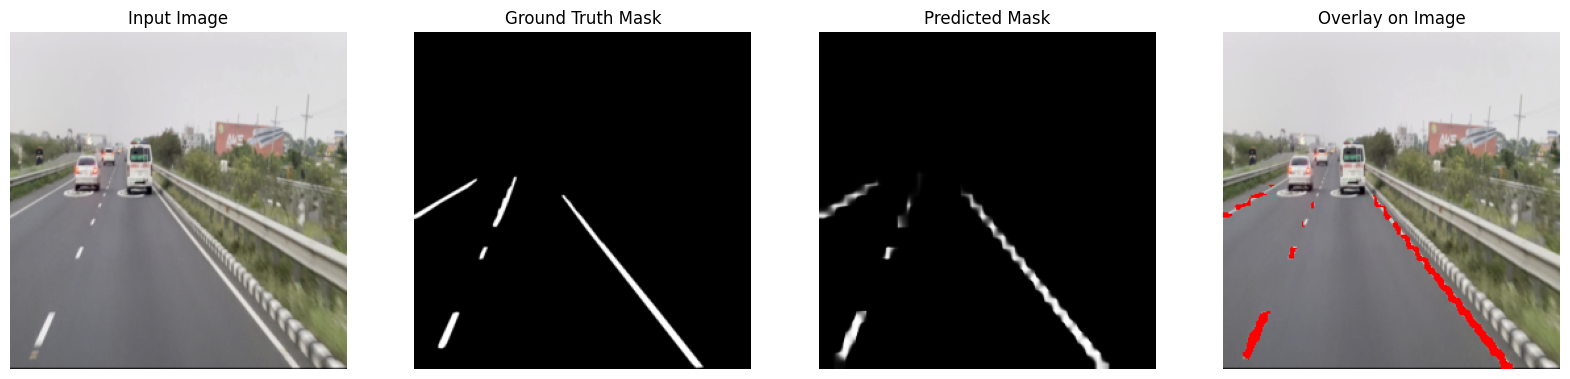

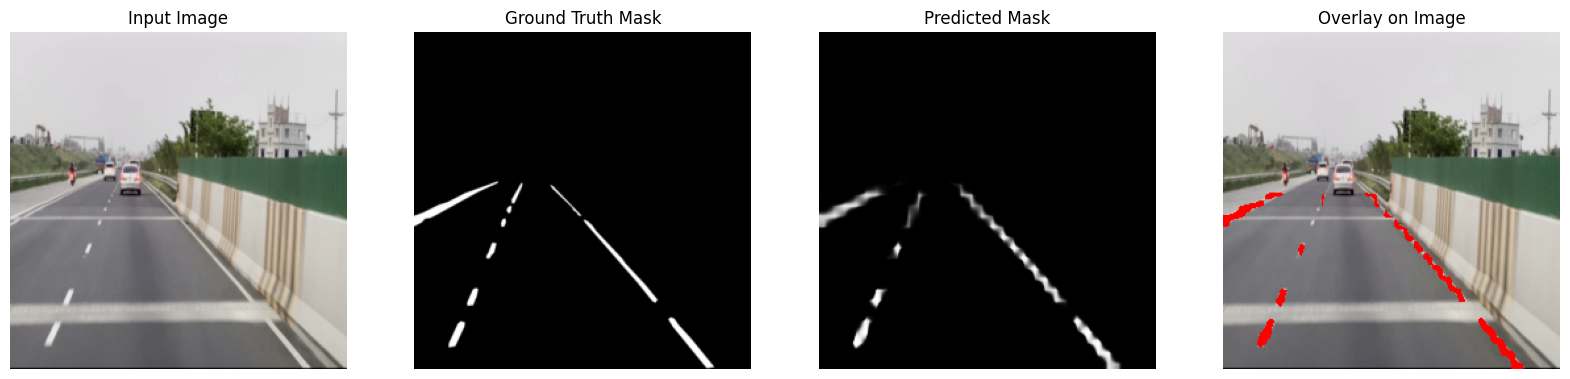

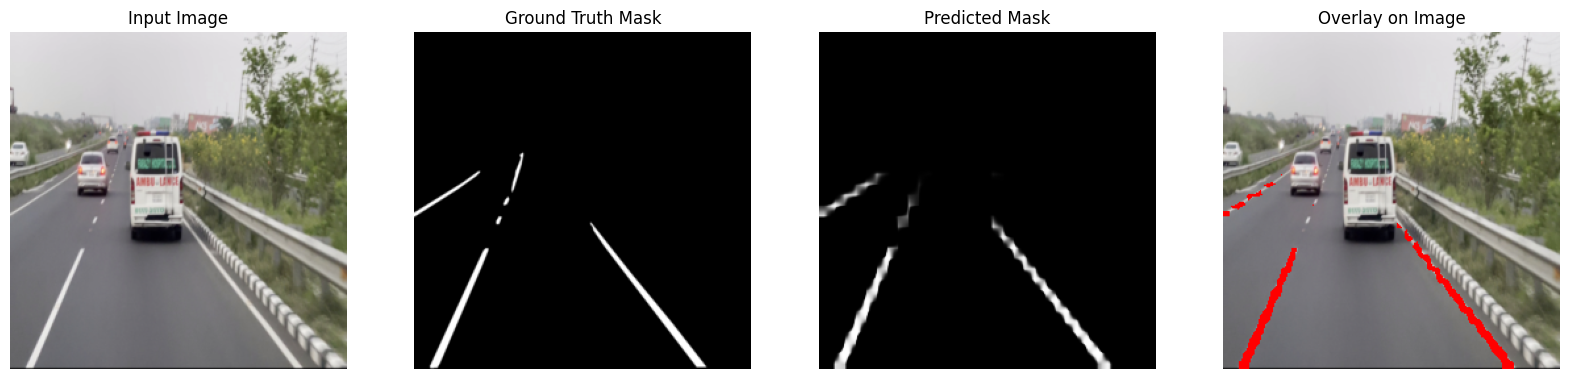

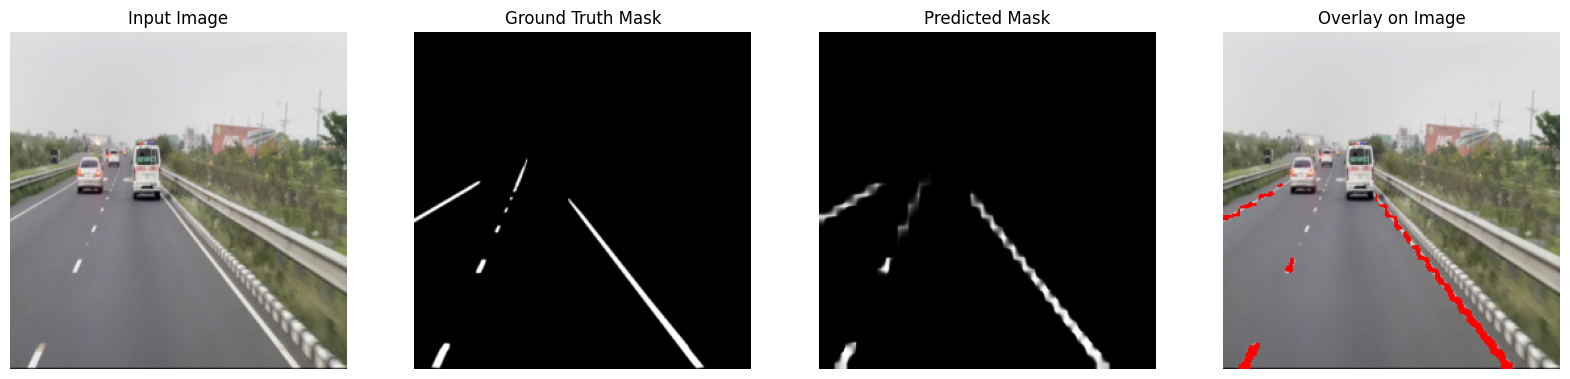

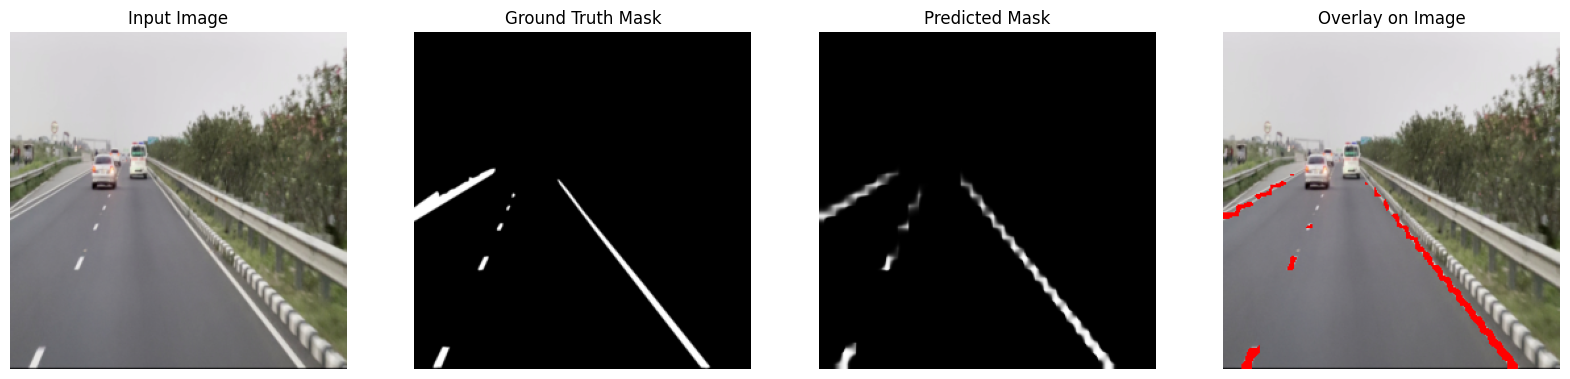

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, num_samples=3):
    """
    Visualizes predictions with input image, ground truth mask, predicted mask, and overlay.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    with torch.no_grad():
        samples_shown = 0
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    return

                # Input Image (convert from tensor to numpy for visualization)
                image = images[i].cpu().numpy()  # Convert to NumPy
                image = image.transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
                image = (image - image.min()) / (image.max() - image.min())  # Normalize to [0, 1]

                # Ground Truth Mask
                mask = masks[i].cpu().squeeze().numpy()

                # Predicted Mask
                pred = outputs[i].cpu().squeeze().numpy()

                # Create overlay
                overlay = image.copy()
                overlay[pred > 0.5] = [1.0, 0.0, 0.0]  # Red color for lane overlay

                # Plot all components
                fig, axes = plt.subplots(1, 4, figsize=(20, 5))
                axes[0].imshow(image)
                axes[0].set_title("Input Image")
                axes[0].axis("off")

                axes[1].imshow(mask, cmap='gray')
                axes[1].set_title("Ground Truth Mask")
                axes[1].axis("off")

                axes[2].imshow(pred, cmap='gray')
                axes[2].set_title("Predicted Mask")
                axes[2].axis("off")

                axes[3].imshow(overlay)
                axes[3].set_title("Overlay on Image")
                axes[3].axis("off")

                plt.show()

                samples_shown += 1

# Load the best model and visualize predictions
model.load_state_dict(torch.load("/content/drive/MyDrive/path_to_model/deeplabv3_lane_detection2.pt"))
visualize_predictions(model, test_loader, num_samples=5)


## DeepLabV3+ (ResNet50) Model Visualization

**```model``` : ``` deeplabv3plus_lane_detection1 ```**

<ipython-input-15-fdb93ced89c9>:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/path_to_model/deeplabv3plus_lane_d

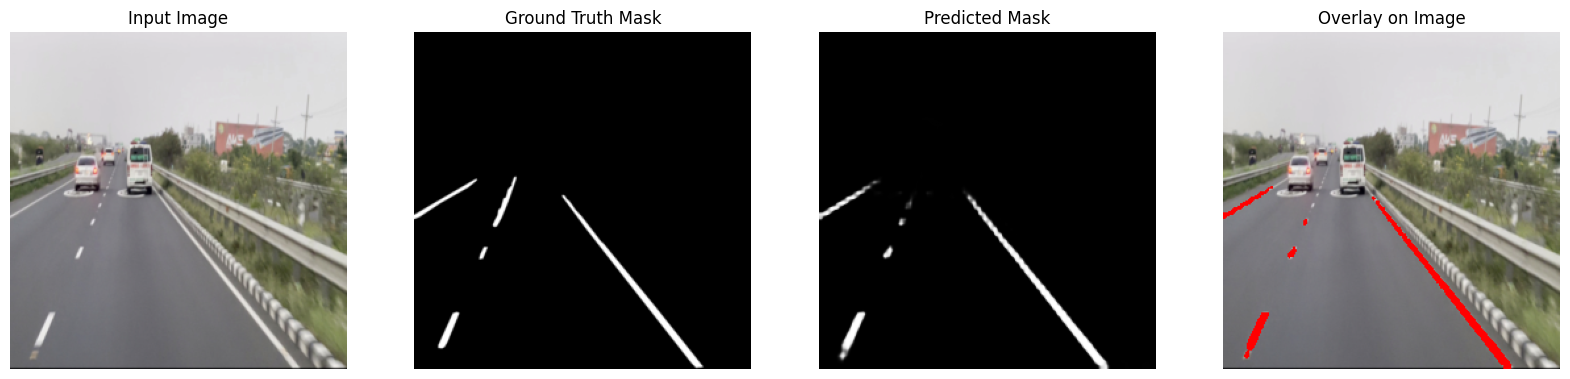

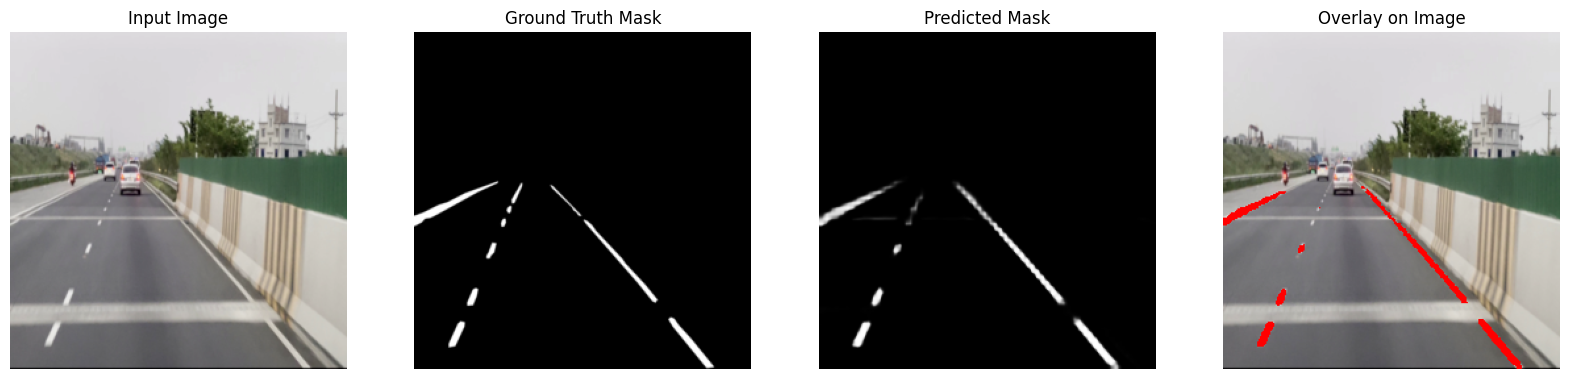

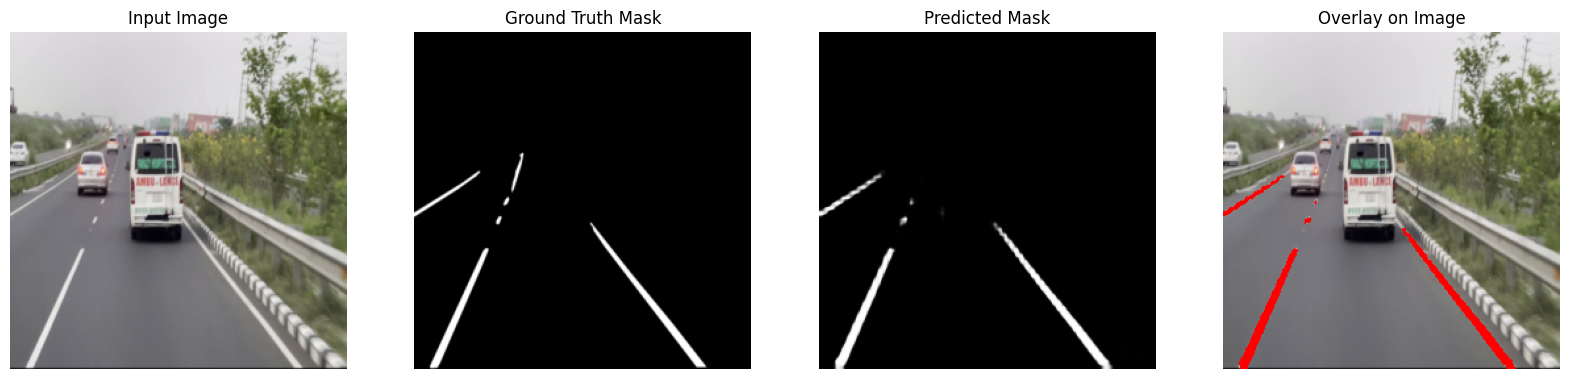

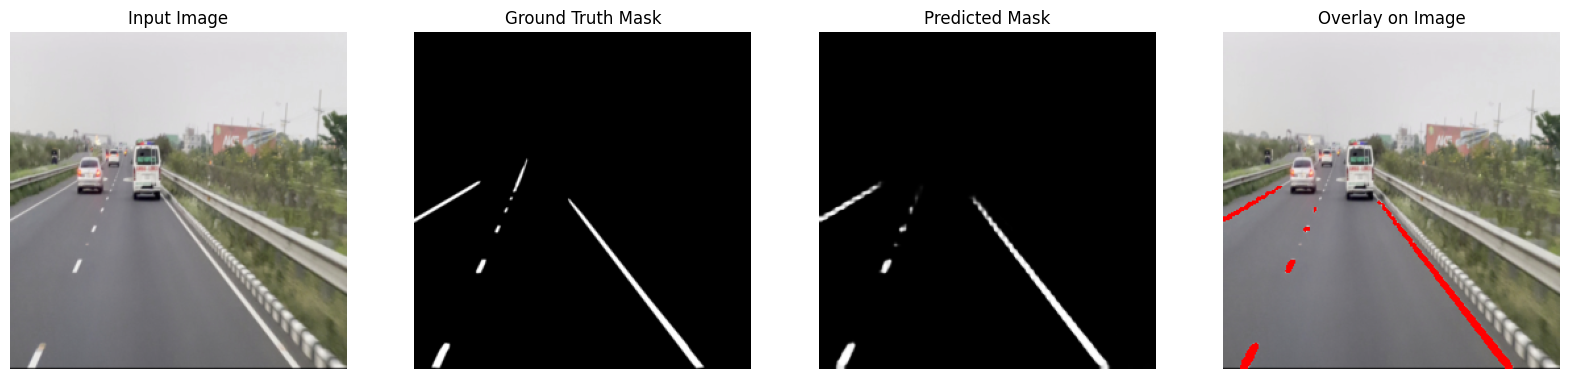

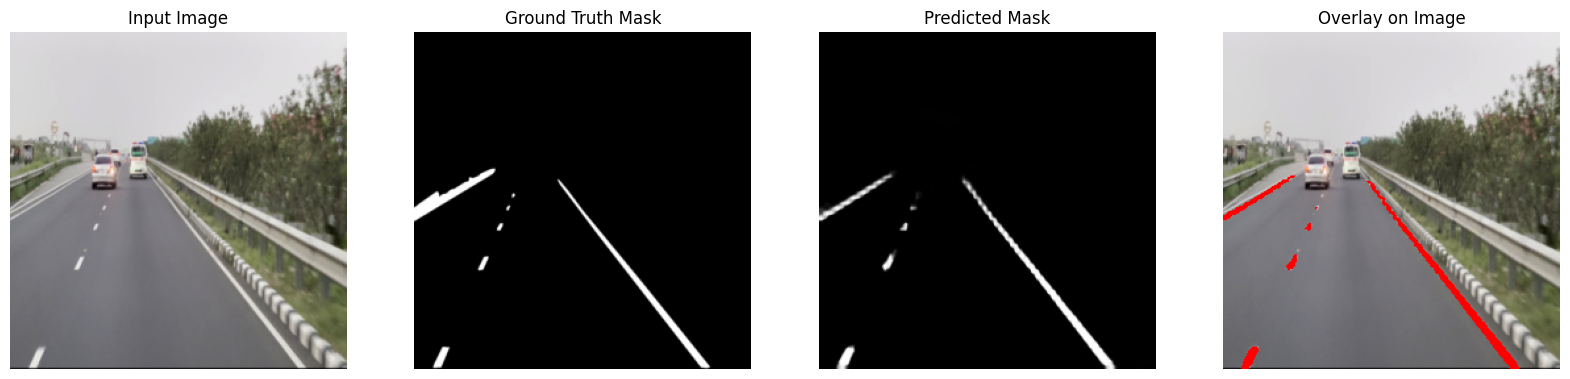

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, num_samples=3):
    """
    Visualizes predictions with input image, ground truth mask, predicted mask, and overlay.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    with torch.no_grad():
        samples_shown = 0
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    return

                # Input Image (convert from tensor to numpy for visualization)
                image = images[i].cpu().numpy()  # Convert to NumPy
                image = image.transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
                image = (image - image.min()) / (image.max() - image.min())  # Normalize to [0, 1]

                # Ground Truth Mask
                mask = masks[i].cpu().squeeze().numpy()

                # Predicted Mask
                pred = outputs[i].cpu().squeeze().numpy()

                # Create overlay
                overlay = image.copy()
                overlay[pred > 0.5] = [1.0, 0.0, 0.0]  # Red color for lane overlay

                # Plot all components
                fig, axes = plt.subplots(1, 4, figsize=(20, 5))
                axes[0].imshow(image)
                axes[0].set_title("Input Image")
                axes[0].axis("off")

                axes[1].imshow(mask, cmap='gray')
                axes[1].set_title("Ground Truth Mask")
                axes[1].axis("off")

                axes[2].imshow(pred, cmap='gray')
                axes[2].set_title("Predicted Mask")
                axes[2].axis("off")

                axes[3].imshow(overlay)
                axes[3].set_title("Overlay on Image")
                axes[3].axis("off")

                plt.show()

                samples_shown += 1

# Load the best model and visualize predictions
model.load_state_dict(torch.load("/content/drive/MyDrive/path_to_model/deeplabv3plus_lane_detection1.pt"))
visualize_predictions(model, test_loader, num_samples=5)


# Evaluation Metrics

## DeepLabV3+ (ResNet50) Evaluation Metrics

### Training Evaluation

**```model``` : ``` deeplabv3plus_lane_detection1 ```**

In [ ]:
import torch
from tqdm import tqdm
import numpy as np

# Define the metrics function
def calculate_metrics(pred, target):
    """
    Calculate pixel accuracy, IoU, precision, and recall for predictions.
    Args:
        pred (torch.Tensor): Predicted binary mask (thresholded).
        target (torch.Tensor): Ground truth mask.

    Returns:
        dict: A dictionary containing accuracy, IoU, precision, and recall.
    """
    pred = (pred > 0.5).float()  # Threshold predictions at 0.5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    true_positive = intersection
    false_positive = (pred * (1 - target)).sum()
    false_negative = ((1 - pred) * target).sum()

    accuracy = (pred == target).float().mean().item()  # Pixel accuracy
    iou = (intersection / union).item() if union > 0 else 0.0  # IoU
    precision = (true_positive / (true_positive + false_positive)).item() if (true_positive + false_positive) > 0 else 0.0
    recall = (true_positive / (true_positive + false_negative)).item() if (true_positive + false_negative) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "iou": iou,
        "precision": precision,
        "recall": recall
    }

# Evaluation function
def evaluate_model(model, dataloader, criterion):
    """
    Evaluate the model on the given dataloader and calculate metrics.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (torch.utils.data.DataLoader): DataLoader for evaluation.
        criterion (torch.nn.Module): Loss function.

    Returns:
        dict: A dictionary containing average loss and metrics.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    total_loss = 0.0
    total_metrics = {"accuracy": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0}
    num_samples = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item() * images.size(0)

            # Calculate metrics
            for i in range(images.size(0)):
                metrics = calculate_metrics(outputs[i], masks[i])
                for key in total_metrics:
                    total_metrics[key] += metrics[key]

            num_samples += images.size(0)

    # Average loss and metrics
    avg_loss = total_loss / num_samples
    avg_metrics = {key: total_metrics[key] / num_samples for key in total_metrics}

    return {"loss": avg_loss, **avg_metrics}

# Load the saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepLabV3Plus(num_classes=1)
model_path = "/content/drive/MyDrive/path_to_model/deeplabv3plus_lane_detection1.pt"
model.load_state_dict(torch.load(model_path, map_location=device))

# Define the loss function
criterion = torch.nn.BCELoss()

# Evaluate the model on the training set
train_metrics = evaluate_model(model, train_loader, criterion)

# Print the results
print(f"Training Evaluation Metrics:")
print(f"Loss: {train_metrics['loss']:.4f}")
print(f"Pixel Accuracy: {train_metrics['accuracy']:.4f}")
print(f"IoU: {train_metrics['iou']:.4f}")
print(f"Precision: {train_metrics['precision']:.4f}")
print(f"Recall: {train_metrics['recall']:.4f}")

<ipython-input-18-4e894e0926bc>:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating: 100%|███████

Training Evaluation Metrics:
Loss: 0.0088
Pixel Accuracy: 0.9880
IoU: 0.6542
Precision: 0.7578
Recall: 0.8133


### Testing Evaluation

**```model``` : ``` deeplabv3plus_lane_detection1 ```**

In [ ]:
import torch
from tqdm import tqdm
import numpy as np

# Define the metrics function
def calculate_metrics(pred, target):
    """
    Calculate pixel accuracy, IoU, precision, and recall for predictions.
    Args:
        pred (torch.Tensor): Predicted binary mask (thresholded).
        target (torch.Tensor): Ground truth mask.

    Returns:
        dict: A dictionary containing accuracy, IoU, precision, and recall.
    """
    pred = (pred > 0.5).float()  # Threshold predictions at 0.5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    true_positive = intersection
    false_positive = (pred * (1 - target)).sum()
    false_negative = ((1 - pred) * target).sum()

    accuracy = (pred == target).float().mean().item()  # Pixel accuracy
    iou = (intersection / union).item() if union > 0 else 0.0  # IoU
    precision = (true_positive / (true_positive + false_positive)).item() if (true_positive + false_positive) > 0 else 0.0
    recall = (true_positive / (true_positive + false_negative)).item() if (true_positive + false_negative) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "iou": iou,
        "precision": precision,
        "recall": recall
    }

# Evaluation function
def evaluate_model(model, dataloader, criterion):
    """
    Evaluate the model on the given dataloader and calculate metrics.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (torch.utils.data.DataLoader): DataLoader for evaluation.
        criterion (torch.nn.Module): Loss function.

    Returns:
        dict: A dictionary containing average loss and metrics.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    total_loss = 0.0
    total_metrics = {"accuracy": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0}
    num_samples = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item() * images.size(0)

            # Calculate metrics
            for i in range(images.size(0)):
                metrics = calculate_metrics(outputs[i], masks[i])
                for key in total_metrics:
                    total_metrics[key] += metrics[key]

            num_samples += images.size(0)

    # Average loss and metrics
    avg_loss = total_loss / num_samples
    avg_metrics = {key: total_metrics[key] / num_samples for key in total_metrics}

    return {"loss": avg_loss, **avg_metrics}

# Load the saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepLabV3Plus(num_classes=1)
model_path = "/content/drive/MyDrive/path_to_model/deeplabv3plus_lane_detection1.pt"
model.load_state_dict(torch.load(model_path, map_location=device))

# Define the loss function
criterion = torch.nn.BCELoss()

# Evaluate the model on the training set
train_metrics = evaluate_model(model, test_loader, criterion)

# Print the results
print(f"Testing Evaluation Metrics:")
print(f"Loss: {train_metrics['loss']:.4f}")
print(f"Pixel Accuracy: {train_metrics['accuracy']:.4f}")
print(f"IoU: {train_metrics['iou']:.4f}")
print(f"Precision: {train_metrics['precision']:.4f}")
print(f"Recall: {train_metrics['recall']:.4f}")

<ipython-input-20-8065e24c9ac0>:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating: 100%|███████

Testing Evaluation Metrics:
Loss: 0.0133
Pixel Accuracy: 0.9840
IoU: 0.6464
Precision: 0.7274
Recall: 0.8600


# Graph Visualization

## Training & validation performance graph ( `DeepLabV3+(ResNet50)` )

In [ ]:
import matplotlib.pyplot as plt

results = [
    {"epoch": 1, "train_loss": 0.1554, "val_loss": 0.0767, "accuracy": 0.9717, "val_accuracy": 0.9848, "iou": 0.1451, "val_iou": 0.3023},
    {"epoch": 2, "train_loss": 0.0532, "val_loss": 0.0408, "accuracy": 0.9871, "val_accuracy": 0.9865, "iou": 0.4807, "val_iou": 0.4964},
    {"epoch": 3, "train_loss": 0.0322, "val_loss": 0.0288, "accuracy": 0.9875, "val_accuracy": 0.9870, "iou": 0.5619, "val_iou": 0.5507},
    {"epoch": 4, "train_loss": 0.0232, "val_loss": 0.0220, "accuracy": 0.9876, "val_accuracy": 0.9871, "iou": 0.5916, "val_iou": 0.5741},
    {"epoch": 5, "train_loss": 0.0186, "val_loss": 0.0184, "accuracy": 0.9877, "val_accuracy": 0.9871, "iou": 0.6086, "val_iou": 0.5932},
    {"epoch": 6, "train_loss": 0.0157, "val_loss": 0.0163, "accuracy": 0.9878, "val_accuracy": 0.9873, "iou": 0.6267, "val_iou": 0.6054},
    {"epoch": 7, "train_loss": 0.0140, "val_loss": 0.0152, "accuracy": 0.9878, "val_accuracy": 0.9872, "iou": 0.6347, "val_iou": 0.6343},
    {"epoch": 8, "train_loss": 0.0126, "val_loss": 0.0147, "accuracy": 0.9878, "val_accuracy": 0.9872, "iou": 0.6469, "val_iou": 0.6048},
    {"epoch": 9, "train_loss": 0.0120, "val_loss": 0.0133, "accuracy": 0.9878, "val_accuracy": 0.9873, "iou": 0.6425, "val_iou": 0.6386},
    {"epoch": 10, "train_loss": 0.0113, "val_loss": 0.0133, "accuracy": 0.9879, "val_accuracy": 0.9872, "iou": 0.6525, "val_iou": 0.6245},
    {"epoch": 11, "train_loss": 0.0107, "val_loss": 0.0131, "accuracy": 0.9879, "val_accuracy": 0.9873, "iou": 0.6604, "val_iou": 0.6129},
    {"epoch": 12, "train_loss": 0.0102, "val_loss": 0.0127, "accuracy": 0.9879, "val_accuracy": 0.9873, "iou": 0.6672, "val_iou": 0.6341},
    {"epoch": 13, "train_loss": 0.0099, "val_loss": 0.0122, "accuracy": 0.9880, "val_accuracy": 0.9873, "iou": 0.6708, "val_iou": 0.6387},
    {"epoch": 14, "train_loss": 0.0094, "val_loss": 0.0118, "accuracy": 0.9880, "val_accuracy": 0.9873, "iou": 0.6750, "val_iou": 0.6388},
    {"epoch": 15, "train_loss": 0.0095, "val_loss": 0.0120, "accuracy": 0.9880, "val_accuracy": 0.9873, "iou": 0.6702, "val_iou": 0.6485},
    {"epoch": 16, "train_loss": 0.0091, "val_loss": 0.0114, "accuracy": 0.9880, "val_accuracy": 0.9873, "iou": 0.6758, "val_iou": 0.6535},
    {"epoch": 17, "train_loss": 0.0090, "val_loss": 0.0120, "accuracy": 0.9880, "val_accuracy": 0.9873, "iou": 0.6806, "val_iou": 0.6361},
    {"epoch": 18, "train_loss": 0.0086, "val_loss": 0.0113, "accuracy": 0.9881, "val_accuracy": 0.9873, "iou": 0.6887, "val_iou": 0.6626},
    {"epoch": 19, "train_loss": 0.0086, "val_loss": 0.0122, "accuracy": 0.9881, "val_accuracy": 0.9874, "iou": 0.6869, "val_iou": 0.6170},
    {"epoch": 20, "train_loss": 0.0087, "val_loss": 0.0119, "accuracy": 0.9880, "val_accuracy": 0.9873, "iou": 0.6825, "val_iou": 0.6418},
    {"epoch": 21, "train_loss": 0.0083, "val_loss": 0.0120, "accuracy": 0.9881, "val_accuracy": 0.9873, "iou": 0.6927, "val_iou": 0.6343},
    {"epoch": 22, "train_loss": 0.0082, "val_loss": 0.0116, "accuracy": 0.9881, "val_accuracy": 0.9874, "iou": 0.6918, "val_iou": 0.6504},
    {"epoch": 23, "train_loss": 0.0080, "val_loss": 0.0115, "accuracy": 0.9881, "val_accuracy": 0.9873, "iou": 0.6999, "val_iou": 0.6576},
]


# Extract data from the results array
epochs = [entry['epoch'] for entry in results]
train_loss = [entry['train_loss'] for entry in results]
val_loss = [entry['val_loss'] for entry in results]
train_iou = [entry['iou'] for entry in results]
val_iou = [entry['val_iou'] for entry in results]

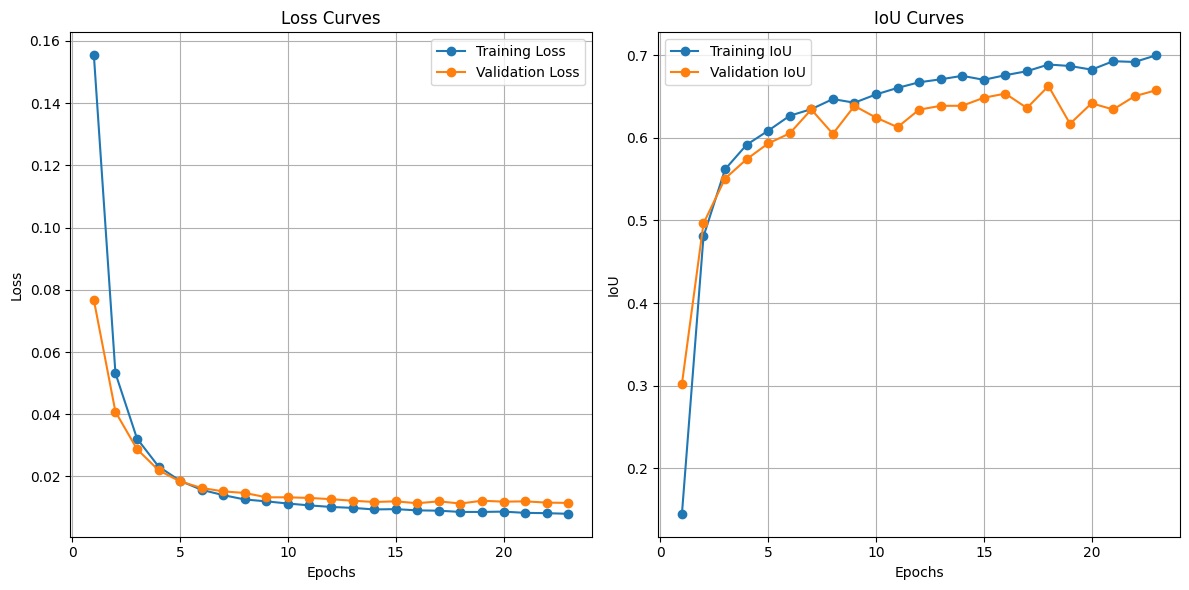

In [ ]:
# Plot the performance graphs
plt.figure(figsize=(12, 6))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# IoU Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_iou, label='Training IoU', marker='o')
plt.plot(epochs, val_iou, label='Validation IoU', marker='o')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('IoU Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Training & validation performance graph ( `DeepLabV3(ResNet50)` )

In [ ]:
import matplotlib.pyplot as plt

results = [
  {
    "epoch": 1,
    "train_loss": 0.286,
    "train_accuracy": 0.9673,
    "train_iou": 0.1079,
    "val_loss": 0.153,
    "val_accuracy": 0.9833,
    "val_iou": 0.2364
  },
  {
    "epoch": 2,
    "train_loss": 0.1036,
    "train_accuracy": 0.9861,
    "train_iou": 0.3377,
    "val_loss": 0.0771,
    "val_accuracy": 0.9853,
    "val_iou": 0.3408
  },
  {
    "epoch": 3,
    "train_loss": 0.0574,
    "train_accuracy": 0.9866,
    "train_iou": 0.394,
    "val_loss": 0.0476,
    "val_accuracy": 0.9855,
    "val_iou": 0.3701
  },
  {
    "epoch": 4,
    "train_loss": 0.0387,
    "train_accuracy": 0.9868,
    "train_iou": 0.422,
    "val_loss": 0.0349,
    "val_accuracy": 0.9863,
    "val_iou": 0.4802
  },
  {
    "epoch": 5,
    "train_loss": 0.0297,
    "train_accuracy": 0.9869,
    "train_iou": 0.4417,
    "val_loss": 0.0277,
    "val_accuracy": 0.9866,
    "val_iou": 0.4864
  },
  {
    "epoch": 6,
    "train_loss": 0.0244,
    "train_accuracy": 0.9871,
    "train_iou": 0.4609,
    "val_loss": 0.0259,
    "val_accuracy": 0.9862,
    "val_iou": 0.482
  },
  {
    "epoch": 7,
    "train_loss": 0.0211,
    "train_accuracy": 0.9872,
    "train_iou": 0.4779,
    "val_loss": 0.0216,
    "val_accuracy": 0.9865,
    "val_iou": 0.4782
  },
  {
    "epoch": 8,
    "train_loss": 0.0189,
    "train_accuracy": 0.9872,
    "train_iou": 0.4913,
    "val_loss": 0.0195,
    "val_accuracy": 0.9868,
    "val_iou": 0.5206
  },
  {
    "epoch": 9,
    "train_loss": 0.0172,
    "train_accuracy": 0.9873,
    "train_iou": 0.5036,
    "val_loss": 0.0182,
    "val_accuracy": 0.9868,
    "val_iou": 0.5165
  },
  {
    "epoch": 10,
    "train_loss": 0.0161,
    "train_accuracy": 0.9874,
    "train_iou": 0.5103,
    "val_loss": 0.017,
    "val_accuracy": 0.9868,
    "val_iou": 0.5341
  },
  {
    "epoch": 11,
    "train_loss": 0.0151,
    "train_accuracy": 0.9875,
    "train_iou": 0.5195,
    "val_loss": 0.0165,
    "val_accuracy": 0.9869,
    "val_iou": 0.5503
  },
  {
    "epoch": 12,
    "train_loss": 0.0145,
    "train_accuracy": 0.9874,
    "train_iou": 0.521,
    "val_loss": 0.0156,
    "val_accuracy": 0.987,
    "val_iou": 0.5474
  },
  {
    "epoch": 13,
    "train_loss": 0.0138,
    "train_accuracy": 0.9875,
    "train_iou": 0.5296,
    "val_loss": 0.0154,
    "val_accuracy": 0.987,
    "val_iou": 0.553
  },
  {
    "epoch": 14,
    "train_loss": 0.0133,
    "train_accuracy": 0.9876,
    "train_iou": 0.5386,
    "val_loss": 0.0159,
    "val_accuracy": 0.9869,
    "val_iou": 0.5382
  },
  {
    "epoch": 15,
    "train_loss": 0.0129,
    "train_accuracy": 0.9876,
    "train_iou": 0.5445,
    "val_loss": 0.0152,
    "val_accuracy": 0.987,
    "val_iou": 0.5505
  },
  {
    "epoch": 16,
    "train_loss": 0.0126,
    "train_accuracy": 0.9876,
    "train_iou": 0.5455,
    "val_loss": 0.0147,
    "val_accuracy": 0.987,
    "val_iou": 0.536
  },
  {
    "epoch": 17,
    "train_loss": 0.0125,
    "train_accuracy": 0.9876,
    "train_iou": 0.5455,
    "val_loss": 0.0148,
    "val_accuracy": 0.9869,
    "val_iou": 0.5569
  },
  {
    "epoch": 18,
    "train_loss": 0.0121,
    "train_accuracy": 0.9877,
    "train_iou": 0.5518,
    "val_loss": 0.0149,
    "val_accuracy": 0.9869,
    "val_iou": 0.5568
  },
  {
    "epoch": 19,
    "train_loss": 0.0118,
    "train_accuracy": 0.9877,
    "train_iou": 0.5559,
    "val_loss": 0.0144,
    "val_accuracy": 0.987,
    "val_iou": 0.5608
  },
  {
    "epoch": 20,
    "train_loss": 0.0117,
    "train_accuracy": 0.9877,
    "train_iou": 0.5599,
    "val_loss": 0.0148,
    "val_accuracy": 0.9871,
    "val_iou": 0.5652
  },
  {
    "epoch": 21,
    "train_loss": 0.0115,
    "train_accuracy": 0.9877,
    "train_iou": 0.5622,
    "val_loss": 0.0141,
    "val_accuracy": 0.987,
    "val_iou": 0.5649
  },
  {
    "epoch": 22,
    "train_loss": 0.0114,
    "train_accuracy": 0.9878,
    "train_iou": 0.5666,
    "val_loss": 0.0139,
    "val_accuracy": 0.9871,
    "val_iou": 0.5754
  },
  {
    "epoch": 23,
    "train_loss": 0.0114,
    "train_accuracy": 0.9877,
    "train_iou": 0.5663,
    "val_loss": 0.0145,
    "val_accuracy": 0.9869,
    "val_iou": 0.5423
  },
  {
    "epoch": 24,
    "train_loss": 0.0111,
    "train_accuracy": 0.9877,
    "train_iou": 0.5699,
    "val_loss": 0.0151,
    "val_accuracy": 0.9869,
    "val_iou": 0.5347
  },
  {
    "epoch": 25,
    "train_loss": 0.0111,
    "train_accuracy": 0.9878,
    "train_iou": 0.5718,
    "val_loss": 0.0143,
    "val_accuracy": 0.987,
    "val_iou": 0.5738
  },
  {
    "epoch": 26,
    "train_loss": 0.011,
    "train_accuracy": 0.9878,
    "train_iou": 0.5743,
    "val_loss": 0.0142,
    "val_accuracy": 0.987,
    "val_iou": 0.5596
  },
  {
    "epoch": 27,
    "train_loss": 0.0108,
    "train_accuracy": 0.9878,
    "train_iou": 0.5781,
    "val_loss": 0.014,
    "val_accuracy": 0.9871,
    "val_iou": 0.5755
  },
  {
    "epoch": 28,
    "train_loss": 0.0107,
    "train_accuracy": 0.9878,
    "train_iou": 0.5829,
    "val_loss": 0.0149,
    "val_accuracy": 0.9869,
    "val_iou": 0.5624
  },
  {
    "epoch": 29,
    "train_loss": 0.0106,
    "train_accuracy": 0.9879,
    "train_iou": 0.5843,
    "val_loss": 0.0151,
    "val_accuracy": 0.987,
    "val_iou": 0.5585
  },
  {
    "epoch": 30,
    "train_loss": 0.0108,
    "train_accuracy": 0.9878,
    "train_iou": 0.5786,
    "val_loss": 0.0147,
    "val_accuracy": 0.987,
    "val_iou": 0.5622
  },
  {
    "epoch": 31,
    "train_loss": 0.0107,
    "train_accuracy": 0.9878,
    "train_iou": 0.5808,
    "val_loss": 0.0137,
    "val_accuracy": 0.9871,
    "val_iou": 0.587
  },
  {
    "epoch": 32,
    "train_loss": 0.0104,
    "train_accuracy": 0.9878,
    "train_iou": 0.5875,
    "val_loss": 0.0138,
    "val_accuracy": 0.987,
    "val_iou": 0.5722
  },
  {
    "epoch": 33,
    "train_loss": 0.0103,
    "train_accuracy": 0.9879,
    "train_iou": 0.5898,
    "val_loss": 0.0142,
    "val_accuracy": 0.9871,
    "val_iou": 0.5836
  },
  {
    "epoch": 34,
    "train_loss": 0.0102,
    "train_accuracy": 0.9879,
    "train_iou": 0.593,
    "val_loss": 0.014,
    "val_accuracy": 0.9871,
    "val_iou": 0.5716
  },
  {
    "epoch": 35,
    "train_loss": 0.01,
    "train_accuracy": 0.9879,
    "train_iou": 0.598,
    "val_loss": 0.015,
    "val_accuracy": 0.987,
    "val_iou": 0.5639
  },
  {
    "epoch": 36,
    "train_loss": 0.0099,
    "train_accuracy": 0.9879,
    "train_iou": 0.6033,
    "val_loss": 0.015,
    "val_accuracy": 0.9872,
    "val_iou": 0.5762
  },
  {
    "epoch": 37,
    "train_loss": 0.0098,
    "train_accuracy": 0.988,
    "train_iou": 0.6055,
    "val_loss": 0.0145,
    "val_accuracy": 0.9872,
    "val_iou": 0.5758
  },
  {
    "epoch": 38,
    "train_loss": 0.0099,
    "train_accuracy": 0.9879,
    "train_iou": 0.602,
    "val_loss": 0.0141,
    "val_accuracy": 0.9871,
    "val_iou": 0.5789
  },
  {
    "epoch": 39,
    "train_loss": 0.0104,
    "train_accuracy": 0.9878,
    "train_iou": 0.5881,
    "val_loss": 0.0148,
    "val_accuracy": 0.987,
    "val_iou": 0.5661
  },
  {
    "epoch": 40,
    "train_loss": 0.0101,
    "train_accuracy": 0.9879,
    "train_iou": 0.5965,
    "val_loss": 0.0149,
    "val_accuracy": 0.987,
    "val_iou": 0.5819
  },
  {
    "epoch": 41,
    "train_loss": 0.0098,
    "train_accuracy": 0.988,
    "train_iou": 0.6065,
    "val_loss": 0.0149,
    "val_accuracy": 0.9871,
    "val_iou": 0.5814
  }
]



# Extract data from the results array
epochs = [entry['epoch'] for entry in results]
train_loss = [entry['train_loss'] for entry in results]
val_loss = [entry['val_loss'] for entry in results]
train_iou = [entry['train_iou'] for entry in results]
val_iou = [entry['val_iou'] for entry in results]

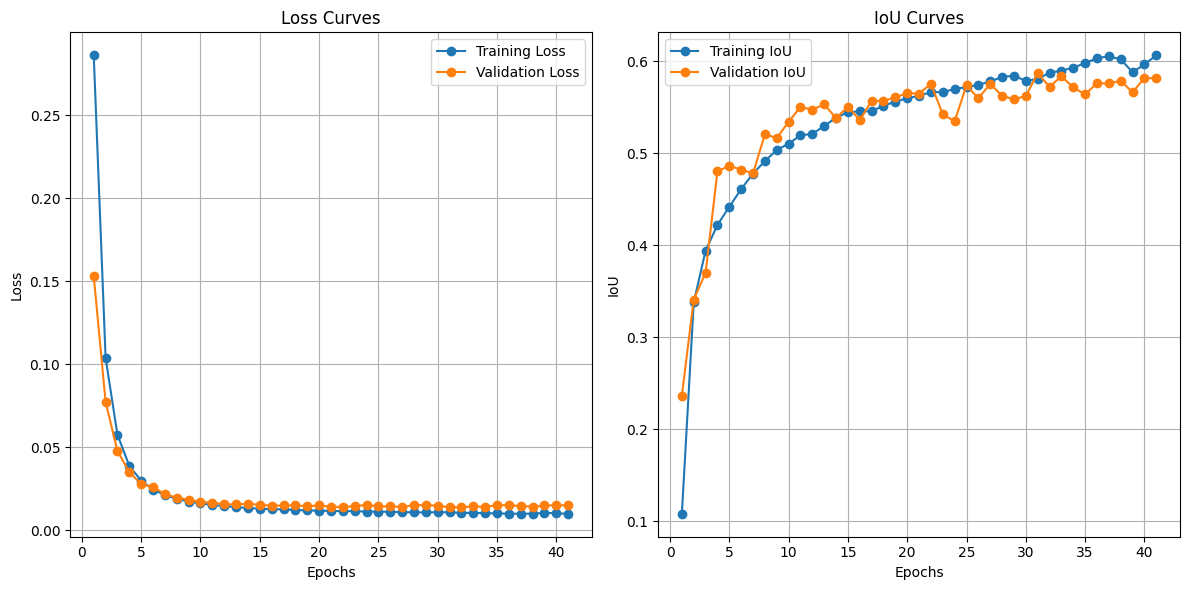

In [ ]:
# Plot the performance graphs
plt.figure(figsize=(12, 6))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# IoU Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_iou, label='Training IoU', marker='o')
plt.plot(epochs, val_iou, label='Validation IoU', marker='o')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('IoU Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()